In [1]:
%pip install numpy scipy matplotlib scikit-learn pandas seaborn spectral

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 4.4 MB/s eta 0:00:00 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [75]:
fruit = "Mango"
if fruit == "Apple" or "Banana":
    print("Yes")
else:
    print("No")

Yes


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Libraries imported successfully.


In [5]:
DATA_PATH = "/Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat"
RESULTS_DIR = "../results"

os.makedirs(RESULTS_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Place aviris_1.mat inside the project's data folder."
    )


In [7]:
mat_contents = loadmat(DATA_PATH)

print("Variables available in the MAT file:")
for key, value in mat_contents.items():
    if not key.startswith("__"):
        print(f"{key}: type={type(value)}, shape={getattr(value, 'shape', None)}")

Variables available in the MAT file:
data: type=<class 'numpy.ndarray'>, shape=(100, 100, 189)
map: type=<class 'numpy.ndarray'>, shape=(100, 100)


In [9]:
cube = mat_contents["data"].astype(np.float32)
ground_truth = mat_contents["map"]

ground_truth = np.squeeze(ground_truth)
ground_truth = (ground_truth > 0).astype(np.uint8)

print("Hyperspectral cube shape:", cube.shape)
print("Ground-truth shape:", ground_truth.shape)
print("Cube data type:", cube.dtype)
print("Ground-truth values:", np.unique(ground_truth))

Hyperspectral cube shape: (100, 100, 189)
Ground-truth shape: (100, 100)
Cube data type: float32
Ground-truth values: [0 1]


In [11]:
height, width, bands = cube.shape

total_pixels = height * width
anomaly_pixels = int(ground_truth.sum())
background_pixels = total_pixels - anomaly_pixels
anomaly_percentage = 100 * anomaly_pixels / total_pixels

print(f"Image height: {height}")
print(f"Image width: {width}")
print(f"Spectral bands: {bands}")
print(f"Total pixels: {total_pixels}")
print(f"Background pixels: {background_pixels}")
print(f"Anomaly pixels: {anomaly_pixels}")
print(f"Anomaly percentage: {anomaly_percentage:.4f}%")

Image height: 100
Image width: 100
Spectral bands: 189
Total pixels: 10000
Background pixels: 9936
Anomaly pixels: 64
Anomaly percentage: 0.6400%


In [13]:
print("Minimum value:", np.nanmin(cube))
print("Maximum value:", np.nanmax(cube))
print("Mean value:", np.nanmean(cube))
print("Standard deviation:", np.nanstd(cube))
print("Number of NaN values:", np.isnan(cube).sum())
print("Number of infinite values:", np.isinf(cube).sum())

Minimum value: 20.0
Maximum value: 7136.0
Mean value: 2652.0164
Standard deviation: 955.27893
Number of NaN values: 0
Number of infinite values: 0


In [15]:
cube = np.nan_to_num(
    cube,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

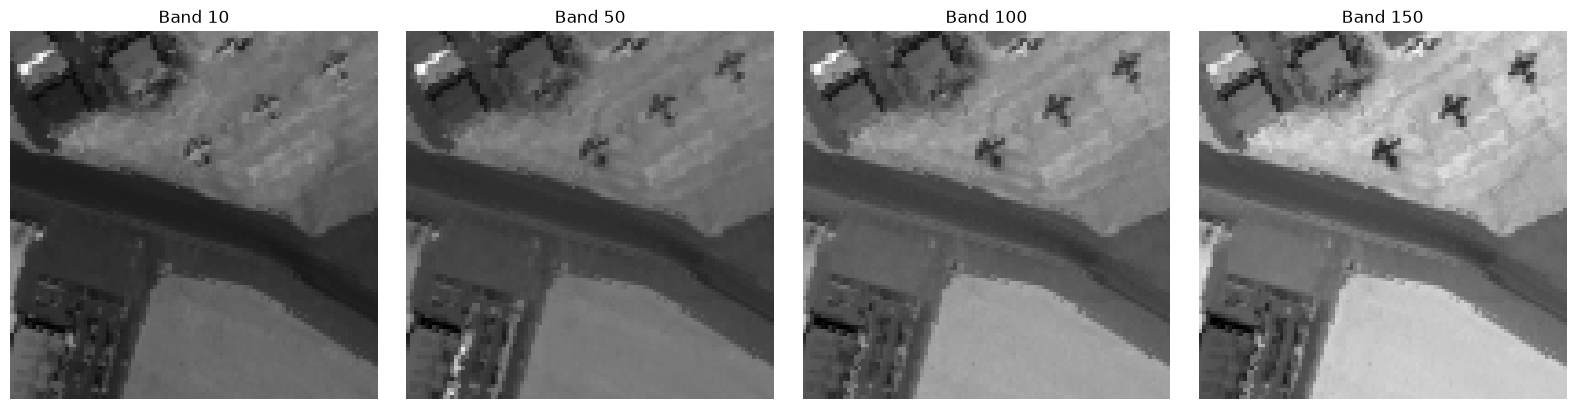

In [17]:
selected_bands = [10, 50, 100, 150]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, band_index in zip(axes, selected_bands):
    ax.imshow(cube[:, :, band_index], cmap="gray")
    ax.set_title(f"Band {band_index}")
    ax.axis("off")

plt.tight_layout()
plt.show()

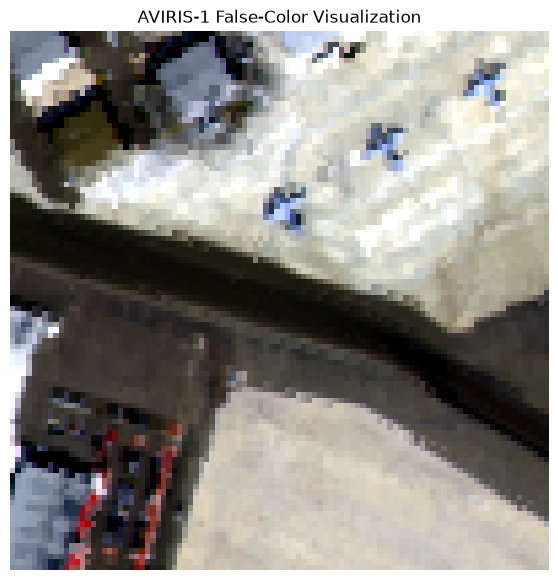

In [19]:
rgb_band_indices = [30, 20, 10]

false_color = cube[:, :, rgb_band_indices].copy()

for channel in range(3):
    channel_data = false_color[:, :, channel]
    
    lower = np.percentile(channel_data, 2)
    upper = np.percentile(channel_data, 98)
    
    channel_data = np.clip(channel_data, lower, upper)
    channel_data = (channel_data - lower) / (upper - lower + 1e-8)
    
    false_color[:, :, channel] = channel_data

plt.figure(figsize=(7, 7))
plt.imshow(false_color)
plt.title("AVIRIS-1 False-Color Visualization")
plt.axis("off")
plt.show()

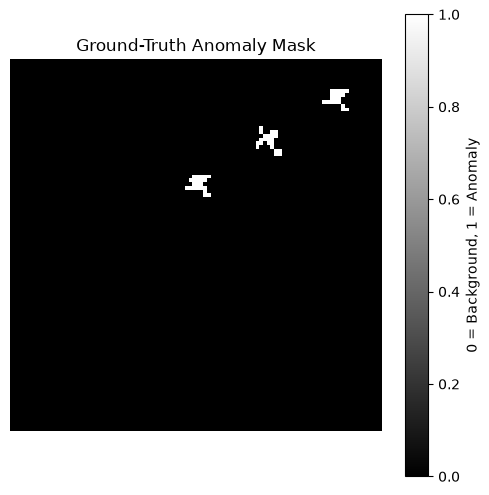

In [21]:
plt.figure(figsize=(6, 6))
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground-Truth Anomaly Mask")
plt.colorbar(label="0 = Background, 1 = Anomaly")
plt.axis("off")
plt.show()

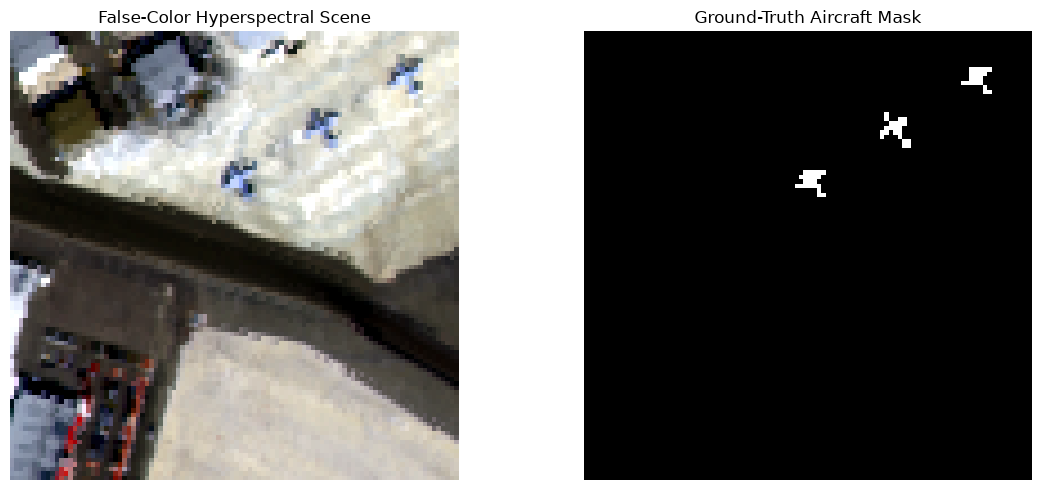

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(false_color)
axes[0].set_title("False-Color Hyperspectral Scene")
axes[0].axis("off")

axes[1].imshow(ground_truth, cmap="gray")
axes[1].set_title("Ground-Truth Aircraft Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

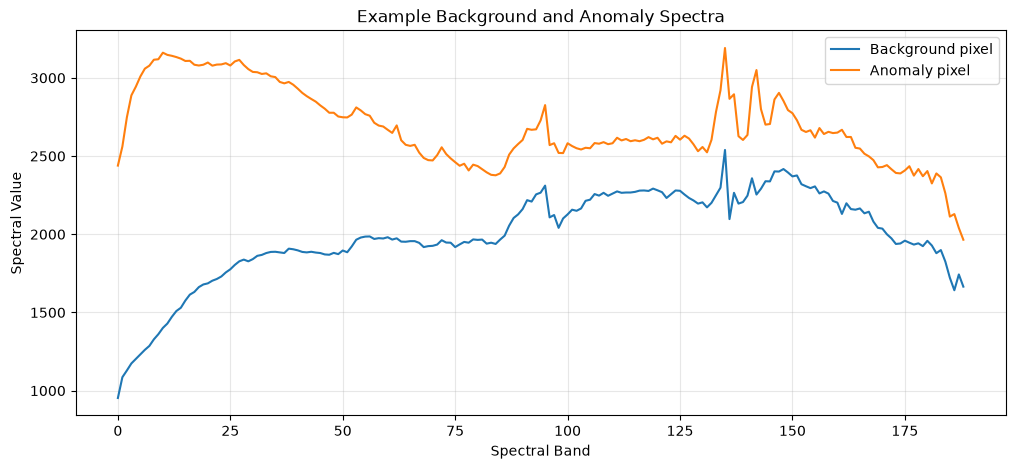

In [25]:
background_coordinates = np.argwhere(ground_truth == 0)
anomaly_coordinates = np.argwhere(ground_truth == 1)

background_row, background_col = background_coordinates[
    np.random.randint(len(background_coordinates))
]

anomaly_row, anomaly_col = anomaly_coordinates[
    np.random.randint(len(anomaly_coordinates))
]

background_spectrum = cube[background_row, background_col, :]
anomaly_spectrum = cube[anomaly_row, anomaly_col, :]

plt.figure(figsize=(12, 5))
plt.plot(background_spectrum, label="Background pixel")
plt.plot(anomaly_spectrum, label="Anomaly pixel")
plt.xlabel("Spectral Band")
plt.ylabel("Spectral Value")
plt.title("Example Background and Anomaly Spectra")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

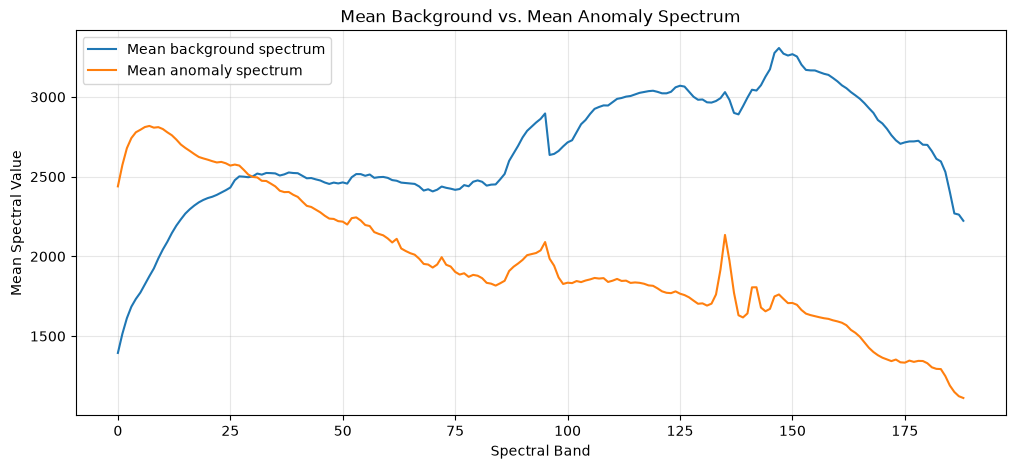

In [27]:
pixels = cube.reshape(-1, bands)
labels = ground_truth.reshape(-1)

background_mean_spectrum = pixels[labels == 0].mean(axis=0)
anomaly_mean_spectrum = pixels[labels == 1].mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(background_mean_spectrum, label="Mean background spectrum")
plt.plot(anomaly_mean_spectrum, label="Mean anomaly spectrum")
plt.xlabel("Spectral Band")
plt.ylabel("Mean Spectral Value")
plt.title("Mean Background vs. Mean Anomaly Spectrum")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [29]:
X = cube.reshape(-1, bands)
y = ground_truth.reshape(-1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (10000, 189)
Label vector shape: (10000,)


In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling:", X_scaled.mean())
print("Standard deviation after scaling:", X_scaled.std())

Mean after scaling: 6.9754464e-09
Standard deviation after scaling: 0.9999999


In [33]:
N_COMPONENTS = 30

pca = PCA(
    n_components=N_COMPONENTS,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(X_scaled)

print("Original feature shape:", X_scaled.shape)
print("PCA feature shape:", X_pca.shape)
print(
    "Total explained variance:",
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

Original feature shape: (10000, 189)
PCA feature shape: (10000, 30)
Total explained variance: 99.98%


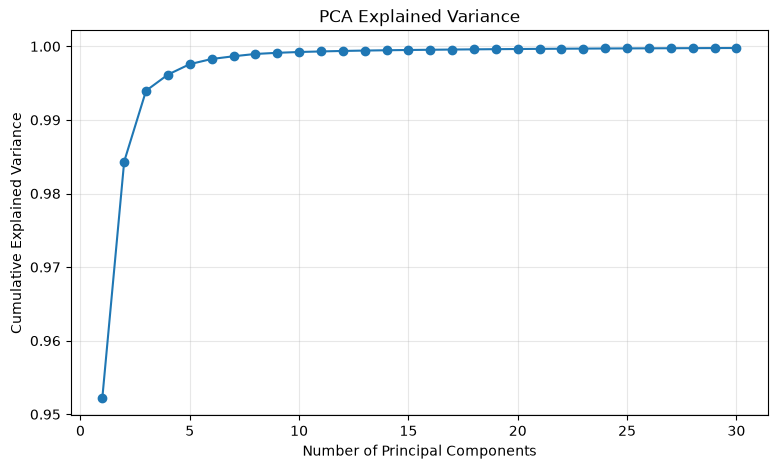

In [35]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, N_COMPONENTS + 1),
    cumulative_variance,
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(alpha=0.3)
plt.show()

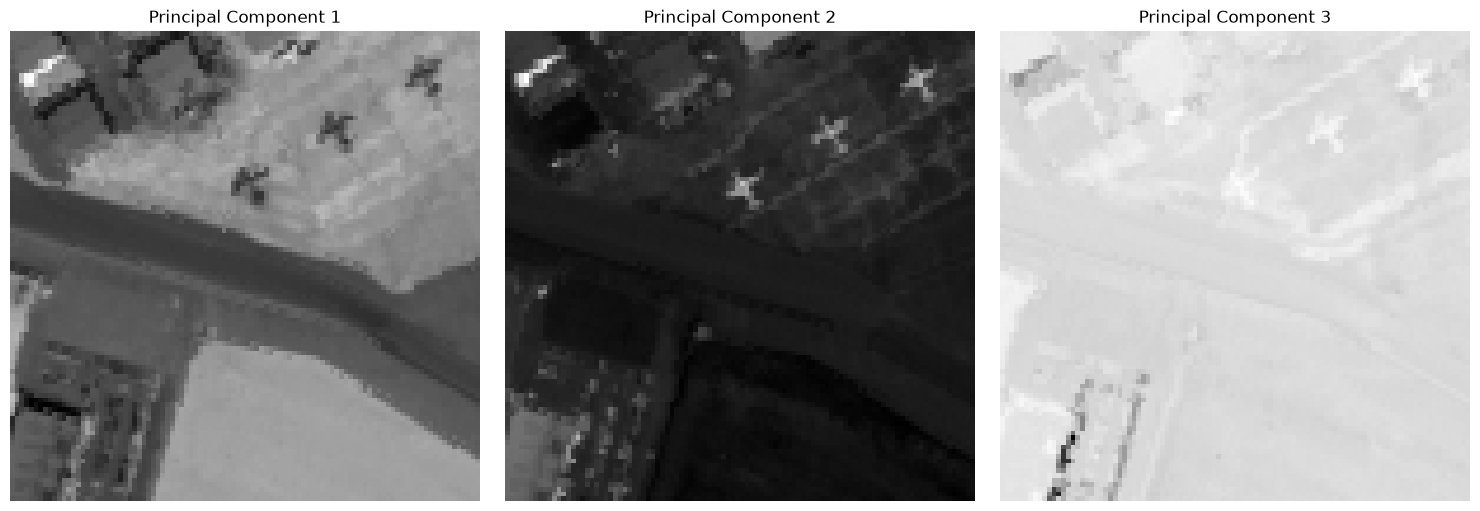

In [37]:
pca_image = X_pca.reshape(height, width, N_COMPONENTS)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for component in range(3):
    axes[component].imshow(
        pca_image[:, :, component],
        cmap="gray"
    )
    axes[component].set_title(f"Principal Component {component + 1}")
    axes[component].axis("off")

plt.tight_layout()
plt.show()

In [39]:
covariance_estimator = LedoitWolf()
covariance_estimator.fit(X_pca)

mean_vector = covariance_estimator.location_
precision_matrix = covariance_estimator.precision_

centered_data = X_pca - mean_vector

rx_scores = np.einsum(
    "ij,jk,ik->i",
    centered_data,
    precision_matrix,
    centered_data
)

print("RX scores calculated.")
print("Minimum RX score:", rx_scores.min())
print("Maximum RX score:", rx_scores.max())
print("Mean RX score:", rx_scores.mean())

RX scores calculated.
Minimum RX score: 4.147748
Maximum RX score: 1116.7251
Mean RX score: 27.275112


In [41]:
rx_map = rx_scores.reshape(height, width)

print("RX anomaly-map shape:", rx_map.shape)

RX anomaly-map shape: (100, 100)


In [43]:
rx_map_normalized = (
    rx_map - rx_map.min()
) / (
    rx_map.max() - rx_map.min() + 1e-8
)

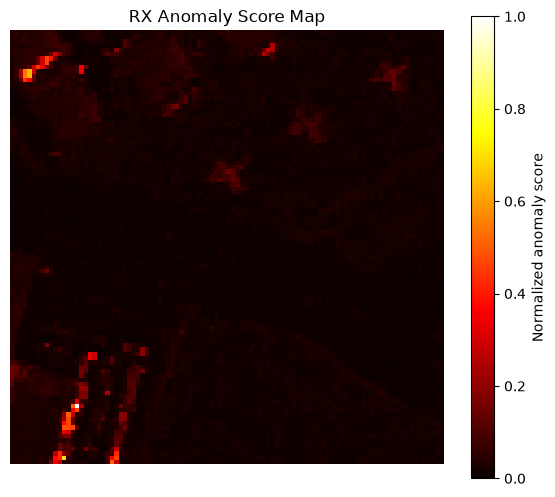

In [45]:
plt.figure(figsize=(7, 6))
plt.imshow(rx_map_normalized, cmap="hot")
plt.title("RX Anomaly Score Map")
plt.colorbar(label="Normalized anomaly score")
plt.axis("off")
plt.show()

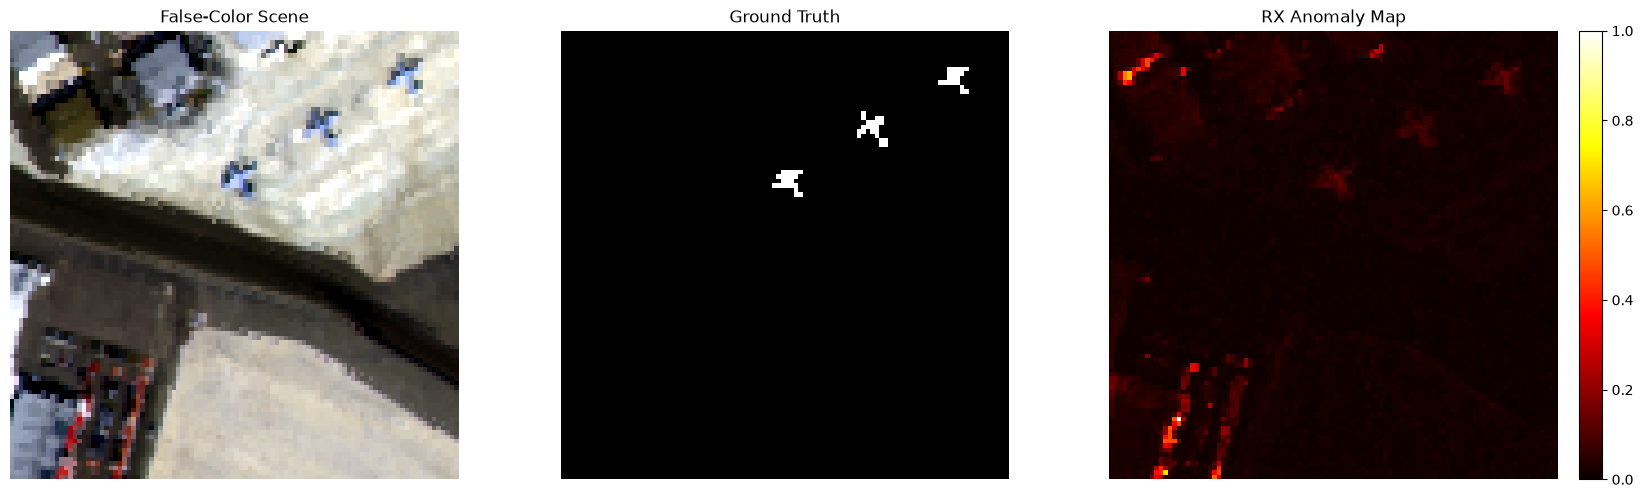

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].imshow(false_color)
axes[0].set_title("False-Color Scene")
axes[0].axis("off")

axes[1].imshow(ground_truth, cmap="gray")
axes[1].set_title("Ground Truth")
axes[1].axis("off")

image = axes[2].imshow(rx_map_normalized, cmap="hot")
axes[2].set_title("RX Anomaly Map")
axes[2].axis("off")

fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [49]:
roc_auc = roc_auc_score(y, rx_scores)
pr_auc = average_precision_score(y, rx_scores)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

ROC-AUC: 0.9753
PR-AUC:  0.1122


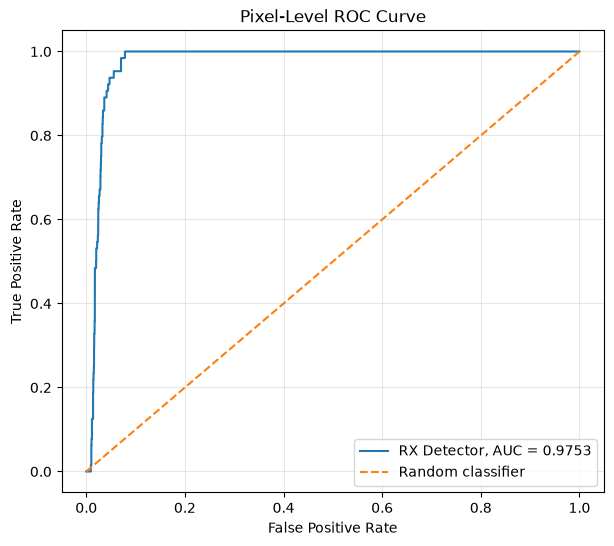

In [51]:
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(
    y,
    rx_scores
)

plt.figure(figsize=(7, 6))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"RX Detector, AUC = {roc_auc:.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Pixel-Level ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

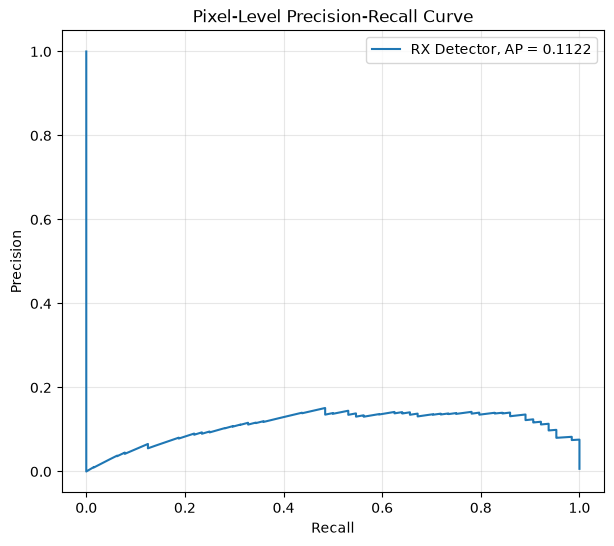

In [53]:
precision, recall, pr_thresholds = precision_recall_curve(
    y,
    rx_scores
)

plt.figure(figsize=(7, 6))
plt.plot(
    recall,
    precision,
    label=f"RX Detector, AP = {pr_auc:.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Pixel-Level Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [55]:
ANOMALY_PERCENTILE = 99

threshold = np.percentile(
    rx_scores,
    ANOMALY_PERCENTILE
)

predicted_mask = (
    rx_scores >= threshold
).astype(np.uint8)

predicted_mask_image = predicted_mask.reshape(height, width)

print("Threshold:", threshold)
print("Predicted anomaly pixels:", predicted_mask.sum())

Threshold: 155.09062515258793
Predicted anomaly pixels: 100


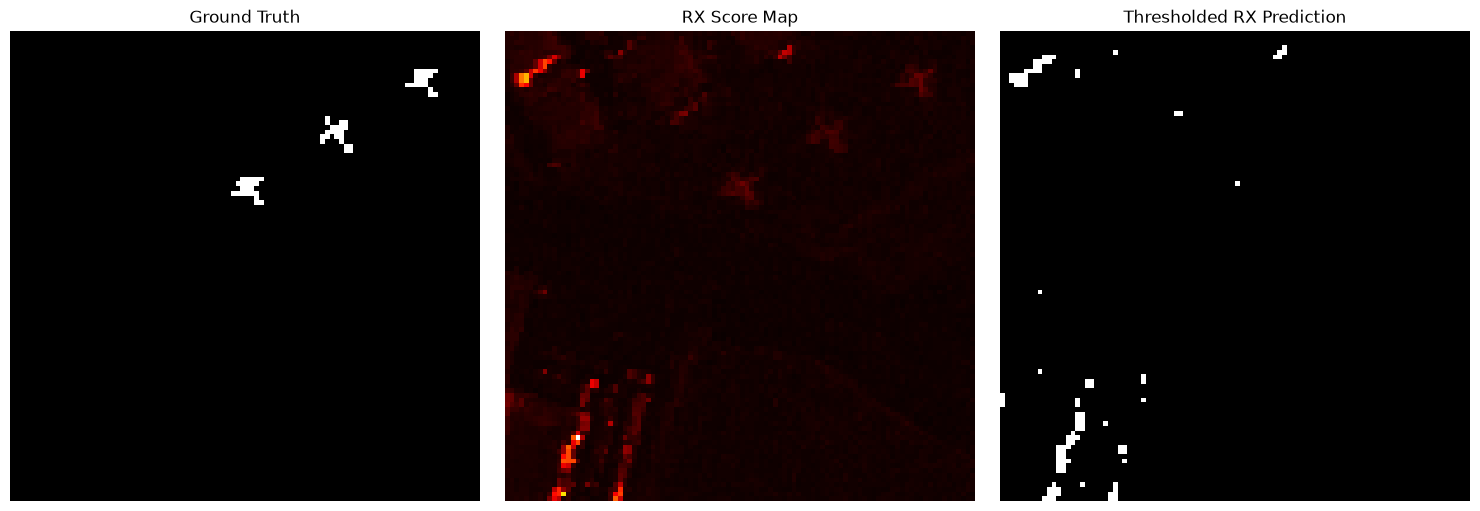

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ground_truth, cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

axes[1].imshow(rx_map_normalized, cmap="hot")
axes[1].set_title("RX Score Map")
axes[1].axis("off")

axes[2].imshow(predicted_mask_image, cmap="gray")
axes[2].set_title("Thresholded RX Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [59]:
print(
    classification_report(
        y,
        predicted_mask,
        target_names=["Background", "Anomaly"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Background     0.9936    0.9900    0.9918      9936
     Anomaly     0.0100    0.0156    0.0122        64

    accuracy                         0.9838     10000
   macro avg     0.5018    0.5028    0.5020     10000
weighted avg     0.9873    0.9838    0.9856     10000



In [61]:
cm = confusion_matrix(y, predicted_mask)

cm_dataframe = pd.DataFrame(
    cm,
    index=["Actual Background", "Actual Anomaly"],
    columns=["Predicted Background", "Predicted Anomaly"]
)

cm_dataframe

,Predicted Background,Predicted Anomaly
Actual Background,9837,99
Actual Anomaly,63,1


In [63]:
tn, fp, fn, tp = cm.ravel()

precision_score_value = tp / (tp + fp + 1e-8)
recall_score_value = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
false_positive_rate_value = fp / (fp + tn + 1e-8)
f1_score_value = (
    2 * precision_score_value * recall_score_value
    / (precision_score_value + recall_score_value + 1e-8)
)

print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True negatives: {tn}")
print(f"Precision: {precision_score_value:.4f}")
print(f"Recall / Detection probability: {recall_score_value:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"False-positive rate: {false_positive_rate_value:.6f}")
print(f"F1-score: {f1_score_value:.4f}")

True positives: 1
False positives: 99
False negatives: 63
True negatives: 9837
Precision: 0.0100
Recall / Detection probability: 0.0156
Specificity: 0.9900
False-positive rate: 0.009964
F1-score: 0.0122


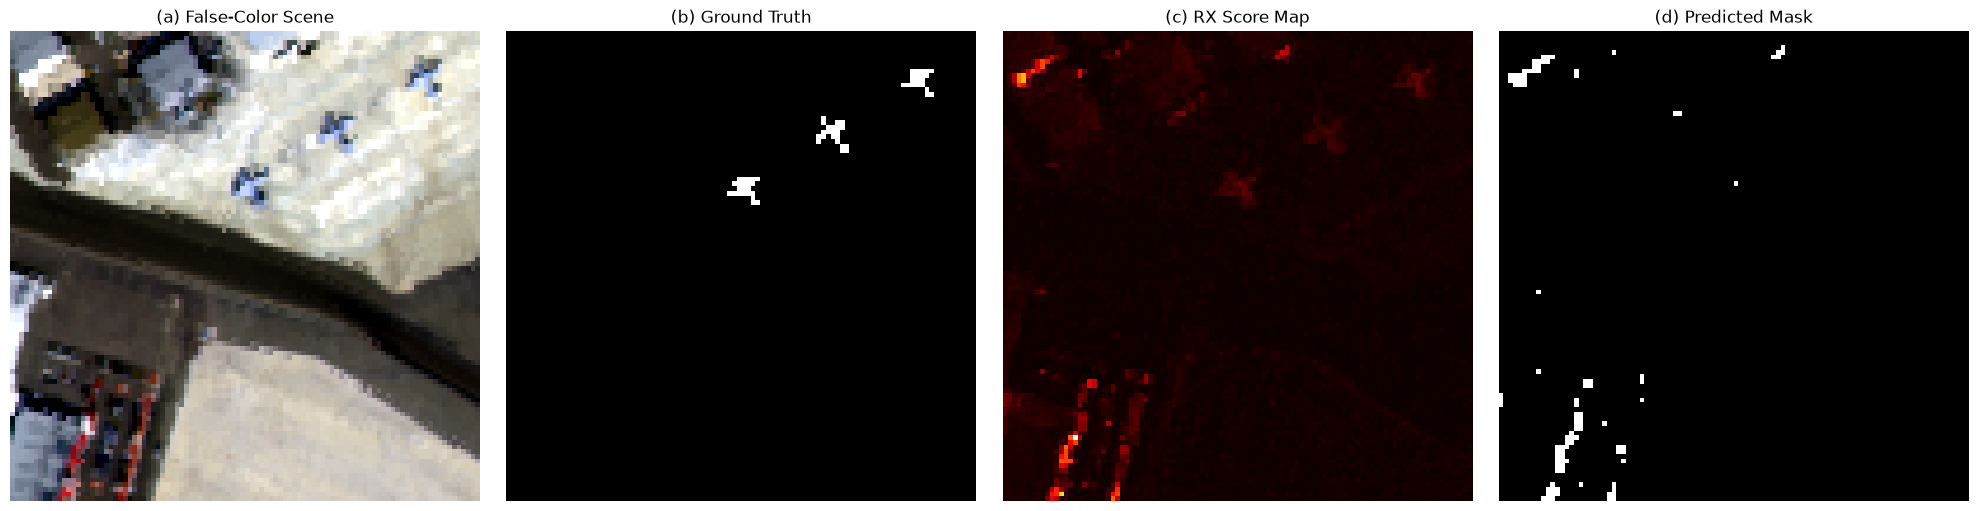

Figure saved to: ../results/aviris_rx_results.png


In [65]:
figure, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(false_color)
axes[0].set_title("(a) False-Color Scene")
axes[0].axis("off")

axes[1].imshow(ground_truth, cmap="gray")
axes[1].set_title("(b) Ground Truth")
axes[1].axis("off")

axes[2].imshow(rx_map_normalized, cmap="hot")
axes[2].set_title("(c) RX Score Map")
axes[2].axis("off")

axes[3].imshow(predicted_mask_image, cmap="gray")
axes[3].set_title("(d) Predicted Mask")
axes[3].axis("off")

plt.tight_layout()

output_path = os.path.join(
    RESULTS_DIR,
    "aviris_rx_results.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", output_path)

In [67]:
results = pd.DataFrame(
    {
        "Dataset": ["AVIRIS-1 San Diego"],
        "Method": ["PCA + Regularized RX"],
        "PCA Components": [N_COMPONENTS],
        "Threshold Percentile": [ANOMALY_PERCENTILE],
        "ROC_AUC": [roc_auc],
        "PR_AUC": [pr_auc],
        "Precision": [precision_score_value],
        "Recall": [recall_score_value],
        "F1": [f1_score_value],
        "False Positive Rate": [false_positive_rate_value]
    }
)

results

,Dataset,Method,PCA Components,Threshold Percentile,ROC_AUC,PR_AUC,Precision,Recall,F1,False Positive Rate
0,AVIRIS-1 San Diego,PCA + Regularized RX,30,99,0.975264,0.112233,0.01,0.015625,0.012195,0.009964


In [69]:
import joblib

joblib.dump(
    scaler,
    os.path.join(RESULTS_DIR, "aviris_standard_scaler.joblib")
)

joblib.dump(
    pca,
    os.path.join(RESULTS_DIR, "aviris_pca.joblib")
)

joblib.dump(
    covariance_estimator,
    os.path.join(RESULTS_DIR, "aviris_rx_covariance.joblib")
)

print("Preprocessing and RX objects saved.")

Preprocessing and RX objects saved.


In [71]:
print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print("Dataset: AVIRIS-1 San Diego")
print(f"Cube shape: {cube.shape}")
print(f"Number of pixels: {len(y)}")
print(f"Number of anomaly pixels: {int(y.sum())}")
print(f"Number of PCA components: {N_COMPONENTS}")
print("Method: Regularized RX Detector")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Threshold percentile: {ANOMALY_PERCENTILE}")
print(f"Precision: {precision_score_value:.4f}")
print(f"Recall: {recall_score_value:.4f}")
print(f"F1-score: {f1_score_value:.4f}")
print("=" * 60)

EXPERIMENT SUMMARY
Dataset: AVIRIS-1 San Diego
Cube shape: (100, 100, 189)
Number of pixels: 10000
Number of anomaly pixels: 64
Number of PCA components: 30
Method: Regularized RX Detector
ROC-AUC: 0.9753
PR-AUC: 0.1122
Threshold percentile: 99
Precision: 0.0100
Recall: 0.0156
F1-score: 0.0122
